In [5]:
import numpy as np
import pandas as pd

In [6]:
embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/20260108_kinetics_morphology_resnet_embeddings_all"

embeddings = np.load(f"{embeddings_dir}/embeddings_raw.npy")
img_paths = pd.read_csv(f"{embeddings_dir}/image_paths.csv", header=None)[0].tolist()
labels = np.load(f"{embeddings_dir}/labels.npy")
label_names = np.load(f"{embeddings_dir}/label_names.npy")

# Split embeddings into a list along first axis
embeddings = [embeddings[i] for i in range(embeddings.shape[0])]

df_data = pd.DataFrame({"image_paths": img_paths, "labels": labels, "embedding": embeddings})
df_metadata = pd.read_csv("/experiments/dhruv_4D_ResnetBiLSTM_phate/kinetics_metadata/phate_kinetics_metadata.csv")

In [7]:
df_data['drug'] = df_data['labels'].apply(lambda x: label_names[x])
df_data['image_paths'] = df_data['image_paths'].apply(lambda x: x.split('encoded_data/')[-1])
df_data['region id'] = -1

(3810, 20, 2048)

In [18]:
df_data.head()

,image_paths,labels,embedding,drug,region id,movie id
0,20250805-1/000009-0.npy,10,"[[0.0077016815, -0.012993559, -0.013889508, -0...",dnp,0,0.0
1,20250829-1/000122-1.npy,21,"[[0.0080825975, -0.016549943, -0.016820833, -0...",cisplatin,2,1.0
2,20250807-2/000357-2.npy,6,"[[-0.0047384137, -0.020014327, -0.0068367394, ...",mitoq,6,2.0
3,20250813-2/000120-1.npy,22,"[[0.00410096, -0.006578749, -0.010597626, -0.0...",rotenone,2,1.0
4,20250806-1/000412-2.npy,1,"[[0.0057328762, -0.021423273, -0.018377014, -0...",p110,7,2.0


In [9]:
df_metadata.head()

,sample id,region id,cell id,movie id,global_start_frame,path
0,20250722-2,0,0,0,0,20250722-2/000000-0.npy
1,20250722-2,0,0,1,20,20250722-2/000000-1.npy
2,20250722-2,0,0,2,40,20250722-2/000000-2.npy
3,20250722-2,0,1,0,0,20250722-2/000001-0.npy
4,20250722-2,0,1,1,20,20250722-2/000001-1.npy


In [10]:
# set the region id in df_data based on matching image paths in df_metadata
for idx, row in df_metadata.iterrows():
    img_path = row['path']
    df_data.loc[df_data['image_paths'] == img_path, 'region id'] = row['region id']
    df_data.loc[df_data['image_paths'] == img_path, 'movie id'] = int(row['movie id'])

In [11]:
df_data.head()

,image_paths,labels,embedding,drug,region id,movie id
0,20250805-1/000009-0.npy,10,"[[0.0077016815, -0.012993559, -0.013889508, -0...",dnp,0,0.0
1,20250829-1/000122-1.npy,21,"[[0.0080825975, -0.016549943, -0.016820833, -0...",cisplatin,2,1.0
2,20250807-2/000357-2.npy,6,"[[-0.0047384137, -0.020014327, -0.0068367394, ...",mitoq,6,2.0
3,20250813-2/000120-1.npy,22,"[[0.00410096, -0.006578749, -0.010597626, -0.0...",rotenone,2,1.0
4,20250806-1/000412-2.npy,1,"[[0.0057328762, -0.021423273, -0.018377014, -0...",p110,7,2.0


In [15]:
# Average last frame per movie id per region per condition and stack regions for per-condition trajectories
phate_data = []
for lbl in np.unique(labels):
    label_name = label_names[lbl]
    df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
    regions = df_condition['region id'].unique()
    for region in regions:
        df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
        movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
        for movie_id in movie_ids:
            df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)

            # Get the last frame of each movie
            embeddings = np.stack(df_movie['embedding'])
            print(embeddings.shape)
            embeddings = np.mean(embeddings, axis=1)
            # embeddings = embeddings[:, -1, :]
            embeddings = np.mean(embeddings, axis=0)
            time = (int(df_movie.at[0, 'region id']) * 20) + 10
            phate_data.append({"drug": label_name, "time": float(time), "embedding": embeddings})
df_phate = pd.DataFrame(phate_data)

(57, 20, 2048)
(57, 20, 2048)
(57, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(56, 20, 2048)
(56, 20, 2048)
(56, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(43, 20, 2048)
(43, 20, 2048)
(43, 20, 2048)
(49, 20, 2048)
(49, 20, 2048)
(49, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(54, 20, 2048)
(61, 20, 2048)
(61, 20, 2048)
(61, 20, 2048)
(49, 20, 2048)
(49, 20, 2048)
(49, 20, 2048)
(57, 20, 2048)
(57, 20, 2048)
(57, 20, 2048)
(55, 20, 2048)
(55, 20, 2048)
(55, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(53, 20, 2048)
(53, 20, 2048)
(53, 20, 2048)
(57, 20, 2048)
(57, 20, 2048)
(57, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(51, 20, 2048)
(63, 20, 2048)
(63, 20, 2048)
(63, 20, 2048)
(66, 20, 2048)
(66, 20, 2048)
(66, 20, 2048)
(58, 20, 2048)
(58, 20, 2048)
(58, 20, 2048)
(42, 20, 2048)
(42, 20, 2048)
(42, 20, 2048)
(50, 20, 2048)
(50, 20, 2048)
(50, 20, 2048)
(54, 20, 2

In [ ]:
# # Average per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
# for lbl in np.unique(labels):
#     label_name = label_names[lbl]
#     df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#         movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#
#             print(np.array(df_movie['embedding']).shape)
#             embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
#             print(embeddings.shape)
#
#             t_start = int(df_movie.at[0, 'region id']) * 20
#             for i in range(len(embeddings)):
#                 t = t_start + i
#                 phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
# df_phate = pd.DataFrame(phate_data)

In [ ]:
# # Average per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
#
# for lbl in np.unique(labels):
#     df_condition = metadata[metadata['label_id'] == lbl].reset_index(drop=True)
#     label_name = df_condition.at[0, 'label_name']
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#
#         movie_ids = df_region['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#             embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
#
#             t_start = df_movie.at[0, 'global_start_frame']
#             for i in range(len(embeddings)):
#                 t = t_start + i
#                 phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
#
# df_phate = pd.DataFrame(phate_data)

In [16]:
df_phate["embedding"][0].shape

(2048,)

In [17]:
# Save to parquet
df_phate.to_parquet("kinetics-20frame_4DMS-2024v2_phate_mean-pooled-mean-frame.parquet", engine='pyarrow', index=False)

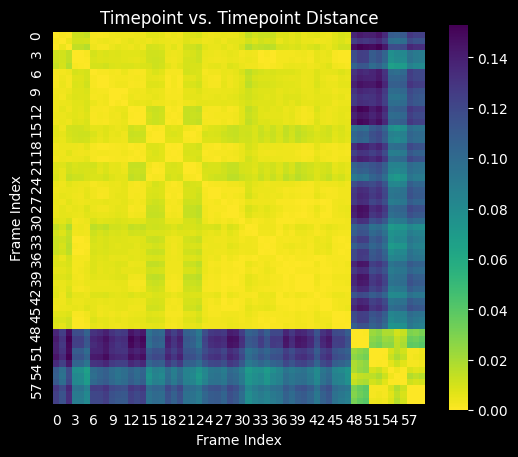

In [20]:
# TESTING

from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
embeddings = np.stack(df_phate['embedding'][:60])


dists = cdist(embeddings, embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Timepoint vs. Timepoint Distance")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()